# Student Depression Dataset

## Objetivo general

Analizar el *Student Depression Dataset* de Kaggle mediante tecnicas de analisis exploratorio de datos y un modelo de regresion, con el fin de identificar relaciones entre variables academicas, demograficas y de estilo de vida que contribuyan a la comprension de los factores asociados a la depresion en estudiantes.

## Objetivos especificos

1. Seleccionar y describir el dataset, identificando variables relevantes relacionadas con la salud mental de los estudiantes.
2. Explorar los datos mediante EDA para identificar distribuciones, tendencias y posibles correlaciones entre presion academica, habitos de sueno y rendimiento academico.
3. Preprocesar el dataset mediante limpieza de datos, tratamiento de valores nulos, codificacion de variables categoricas y normalizacion cuando sea necesario.
4. Desarrollar un modelo de regresion logistica para analizar la relacion entre `Depression_Status` y las variables independientes seleccionadas.
5. Evaluar el desempeno del modelo con metricas adecuadas para clasificacion binaria.
6. Interpretar los resultados para identificar los factores mas influyentes en la depresion estudiantil y su posible aplicacion en estrategias de prevencion.


## 1. Instalacion e importacion de librerias

La celda de instalacion es util si el notebook se ejecuta en Google Colab. Si ya tienes las librerias instaladas, puedes omitirla.

In [1]:
%pip install -q pandas numpy matplotlib seaborn scikit-learn kagglehub

In [2]:
from pathlib import Path
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
pd.set_option('display.max_columns', None)

## 2. Carga del dataset

El dataset se importa directamente desde Kaggle mediante KaggleHub, usando el identificador `hopesb/student-depression-dataset`.


In [3]:
DATASET_HANDLE = 'hopesb/student-depression-dataset'



import kagglehub
print('No se encontro un CSV local. Descargando dataset desde KaggleHub...')
dataset_path = Path(kagglehub.dataset_download(DATASET_HANDLE))
csv_files = list(dataset_path.rglob('*.csv'))
if not csv_files:
    raise FileNotFoundError('No se encontro ningun archivo CSV en el dataset descargado.')
csv_path = csv_files[0]

df = pd.read_csv(csv_path)
print(f'Dataset cargado desde: {csv_path}')
print(f'Filas: {df.shape[0]:,} | Columnas: {df.shape[1]:,}')

No se encontro un CSV local. Descargando dataset desde KaggleHub...
Using Colab cache for faster access to the 'student-depression-dataset' dataset.
Dataset cargado desde: /kaggle/input/student-depression-dataset/Student Depression Dataset.csv
Filas: 27,901 | Columnas: 18


In [4]:
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


## 3. Descripcion inicial de variables

Esta seccion permite identificar tipos de datos, valores nulos y variables disponibles para el analisis.

In [5]:
resumen_columnas = pd.DataFrame({
    'columna': df.columns,
    'tipo_dato': df.dtypes.astype(str).values,
    'nulos': df.isna().sum().values,
    'porcentaje_nulos': (df.isna().mean().values * 100).round(2),
    'valores_unicos': df.nunique(dropna=True).values,
})

resumen_columnas

,columna,tipo_dato,nulos,porcentaje_nulos,valores_unicos
0,id,int64,0,0.00,27901
1,Gender,object,0,0.00,2
2,Age,float64,0,0.00,34
3,City,object,0,0.00,52
4,Profession,object,0,0.00,14
5,Academic Pressure,float64,0,0.00,6
6,Work Pressure,float64,0,0.00,3
7,CGPA,float64,0,0.00,332
8,Study Satisfaction,float64,0,0.00,6
9,Job Satisfaction,float64,0,0.00,5


In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,27901.0,NaN,NaN,NaN,70442.149421,40641.175216,2.0,35039.0,70684.0,105818.0,140699.0
Gender,27901,2,Male,15547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,27901.0,NaN,NaN,NaN,25.8223,4.905687,18.0,21.0,25.0,30.0,59.0
City,27901,52,Kalyan,1570,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Profession,27901,14,Student,27870,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Academic Pressure,27901.0,NaN,NaN,NaN,3.141214,1.381465,0.0,2.0,3.0,4.0,5.0
Work Pressure,27901.0,NaN,NaN,NaN,0.00043,0.043992,0.0,0.0,0.0,0.0,5.0
CGPA,27901.0,NaN,NaN,NaN,7.656104,1.470707,0.0,6.29,7.77,8.92,10.0
Study Satisfaction,27901.0,NaN,NaN,NaN,2.943837,1.361148,0.0,2.0,3.0,4.0,5.0
Job Satisfaction,27901.0,NaN,NaN,NaN,0.000681,0.044394,0.0,0.0,0.0,0.0,4.0


## 4. Definicion de la variable objetivo

El objetivo del proyecto se trabajara como `Depression_Status`. Si el dataset trae la columna con otro nombre, por ejemplo `Depression`, se renombra para mantener coherencia con los objetivos.

In [7]:
target_candidates = [
    'Depression_Status',
    'Depression Status',
    'Depression',
    'depression',
]

target_original = next((col for col in target_candidates if col in df.columns), None)

if target_original is None:
    raise ValueError(f'No se encontro la variable objetivo. Columnas disponibles: {list(df.columns)}')

if target_original != 'Depression_Status':
    df = df.rename(columns={target_original: 'Depression_Status'})

TARGET = 'Depression_Status'
print(f'Variable objetivo usada: {TARGET}')
df[TARGET].value_counts(dropna=False)

Variable objetivo usada: Depression_Status


,count
Depression_Status,
1,16336
0,11565


## 4.1 Limpieza de variables (extendida)

En esta seccion se aplica una limpieza mas estricta antes del EDA y del modelo. Ademas de duplicados y tipos de datos, se normalizan categorias clave (por ejemplo, `Sleep Duration`) y se convierten valores inconsistentes (como `Other`) en nulos para evitar ruido en el analisis.

Al final se construye `df_final`, que es el dataset limpio que se usa en todos los apartados siguientes.

In [8]:
df_original = df.copy()
filas_iniciales, columnas_iniciales = df.shape

# 1. Copia de trabajo y eliminacion de filas duplicadas exactas
df_limpio = df.copy()
duplicados_exactos = df_limpio.duplicated().sum()
df_limpio = df_limpio.drop_duplicates().reset_index(drop=True)

# 2. Limpieza general de variables categoricas
tokens_nulos = {
    '', ' ', 'nan', 'none', 'null', 'na', 'n/a', 'unknown',
    'not available', 'prefer not to say', 'other', 'others'
}

columnas_texto = df_limpio.select_dtypes(include='object').columns.tolist()
for col in columnas_texto:
    serie = df_limpio[col].astype(str).str.strip().str.replace(r'\s+', ' ', regex=True)
    mascara_nulo = serie.str.lower().isin(tokens_nulos)
    serie = serie.mask(mascara_nulo, np.nan)
    df_limpio[col] = serie

# 3. Estandarizacion de categorias frecuentes
columnas_si_no = ['Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']
for col in columnas_si_no:
    if col in df_limpio.columns:
        normalizada = df_limpio[col].astype(str).str.strip().str.lower()
        df_limpio[col] = normalizada.map({
            'yes': 'Yes', 'y': 'Yes', 'si': 'Yes', 'sí': 'Yes',
            'no': 'No', 'n': 'No'
        })

if 'Gender' in df_limpio.columns:
    normalizada = df_limpio['Gender'].astype(str).str.strip().str.lower()
    df_limpio['Gender'] = normalizada.map({
        'male': 'Male', 'm': 'Male',
        'female': 'Female', 'f': 'Female',
    })

if 'Dietary Habits' in df_limpio.columns:
    normalizada = df_limpio['Dietary Habits'].astype(str).str.strip().str.lower()
    df_limpio['Dietary Habits'] = normalizada.map({
        'healthy': 'Healthy',
        'moderate': 'Moderate',
        'unhealthy': 'Unhealthy',
    })

def normalizar_sleep_duration(valor):
    if pd.isna(valor):
        return np.nan

    texto = str(valor).strip().lower()
    if texto in {'other', 'others', 'unknown', 'n/a', 'na', 'none', 'nan'}:
        return np.nan

    mapeo_directo = {
        'less than 5 hours': 'Less than 5 hours',
        '<5 hours': 'Less than 5 hours',
        'below 5 hours': 'Less than 5 hours',
        'under 5 hours': 'Less than 5 hours',
        '5-6 hours': '5-6 hours',
        '5 to 6 hours': '5-6 hours',
        '5-6 hrs': '5-6 hours',
        '7-8 hours': '7-8 hours',
        '7 to 8 hours': '7-8 hours',
        '7-8 hrs': '7-8 hours',
        'more than 8 hours': 'More than 8 hours',
        '>8 hours': 'More than 8 hours',
        '8+ hours': 'More than 8 hours',
        'more than 8 hrs': 'More than 8 hours',
    }

    return mapeo_directo.get(texto, np.nan)

if 'Sleep Duration' in df_limpio.columns:
    df_limpio['Sleep Duration'] = df_limpio['Sleep Duration'].apply(normalizar_sleep_duration)

# 4. Conversion de variables numericas esperadas
columnas_numericas_esperadas = [
    'Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction',
    'Job Satisfaction', 'Work/Study Hours', 'Financial Stress', TARGET
]
for col in columnas_numericas_esperadas:
    if col in df_limpio.columns:
        df_limpio[col] = pd.to_numeric(df_limpio[col], errors='coerce')

# 5. Normalizacion de la variable objetivo
if TARGET in df_limpio.columns and not pd.api.types.is_numeric_dtype(df_limpio[TARGET]):
    objetivo_normalizado = df_limpio[TARGET].astype(str).str.strip().str.lower()
    mapa_objetivo = {
        'yes': 1, 'y': 1, 'si': 1, 'sí': 1, 'true': 1, 'depressed': 1, '1': 1,
        'no': 0, 'n': 0, 'false': 0, 'not depressed': 0, '0': 0,
    }
    df_limpio[TARGET] = objetivo_normalizado.map(mapa_objetivo)

# 6. Revision de rangos validos; valores fuera de rango se marcan como nulos
rangos_validos = {
    'Age': (15, 60),
    'Academic Pressure': (0, 5),
    'Work Pressure': (0, 5),
    'CGPA': (0, 10),
    'Study Satisfaction': (0, 5),
    'Job Satisfaction': (0, 5),
    'Work/Study Hours': (0, 24),
    'Financial Stress': (0, 5),
}

valores_fuera_rango = {}
for col, (minimo, maximo) in rangos_validos.items():
    if col in df_limpio.columns:
        mascara = df_limpio[col].notna() & ~df_limpio[col].between(minimo, maximo)
        valores_fuera_rango[col] = int(mascara.sum())
        df_limpio.loc[mascara, col] = np.nan

# 7. Eliminacion de variables no informativas
columnas_id = [c for c in df_limpio.columns if c.lower() in ['id', 'student_id', 'student id']]
duplicados_id = 0
if columnas_id:
    duplicados_id = int(df_limpio.duplicated(subset=columnas_id).sum())
    df_limpio = df_limpio.drop_duplicates(subset=columnas_id, keep='first')

columnas_constantes = [
    col for col in df_limpio.columns
    if col != TARGET and df_limpio[col].nunique(dropna=True) <= 1
]
columnas_a_eliminar = columnas_id + columnas_constantes
df_limpio = df_limpio.drop(columns=columnas_a_eliminar, errors='ignore')

# 8. Dataset final limpio para todo el flujo
if TARGET in df_limpio.columns:
    df_limpio = df_limpio[df_limpio[TARGET].isin([0, 1])].copy()
    df_limpio[TARGET] = df_limpio[TARGET].astype(int)

df_final = df_limpio.reset_index(drop=True)

# 9. Reporte de limpieza
reporte_limpieza = pd.DataFrame({
    'metrica': [
        'Filas iniciales',
        'Columnas iniciales',
        'Duplicados exactos eliminados',
        'Duplicados por ID eliminados',
        'Filas finales',
        'Columnas finales',
        'Variables eliminadas'
    ],
    'valor': [
        filas_iniciales,
        columnas_iniciales,
        int(duplicados_exactos),
        duplicados_id,
        df_final.shape[0],
        df_final.shape[1],
        ', '.join(columnas_a_eliminar) if columnas_a_eliminar else 'Ninguna'
    ]
})

print('Valores fuera de rango convertidos a nulos:')
display(pd.Series(valores_fuera_rango, name='cantidad').to_frame())

if 'Sleep Duration' in df_final.columns:
    print('Categorias finales de Sleep Duration:')
    display(df_final['Sleep Duration'].value_counts(dropna=False))

display(reporte_limpieza)

# Para compatibilidad con celdas previas
df = df_final.copy()
df_final.head()

Valores fuera de rango convertidos a nulos:


,cantidad
Age,0
Academic Pressure,0
Work Pressure,0
CGPA,0
Study Satisfaction,0
Job Satisfaction,0
Work/Study Hours,0
Financial Stress,0


Categorias finales de Sleep Duration:


,count
Sleep Duration,
Less than 5 hours,8310
7-8 hours,7346
5-6 hours,6183
More than 8 hours,6044
NaN,18


,metrica,valor
0,Filas iniciales,27901
1,Columnas iniciales,18
2,Duplicados exactos eliminados,0
3,Duplicados por ID eliminados,0
4,Filas finales,27901
5,Columnas finales,17
6,Variables eliminadas,id


,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression_Status
0,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


## 5. Analisis exploratorio de datos, EDA

A partir de este punto se utiliza `df_final` (dataset limpio final). Se revisan distribuciones, relaciones y posibles patrones asociados a la depresion.

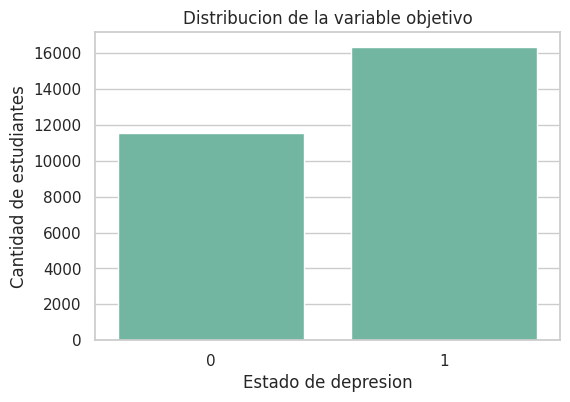

,porcentaje
Depression_Status,
1,58.55
0,41.45


In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_final, x=TARGET)
plt.title('Distribucion de la variable objetivo')
plt.xlabel('Estado de depresion')
plt.ylabel('Cantidad de estudiantes')
plt.show()

df_final[TARGET].value_counts(normalize=True).mul(100).round(2).rename('porcentaje')

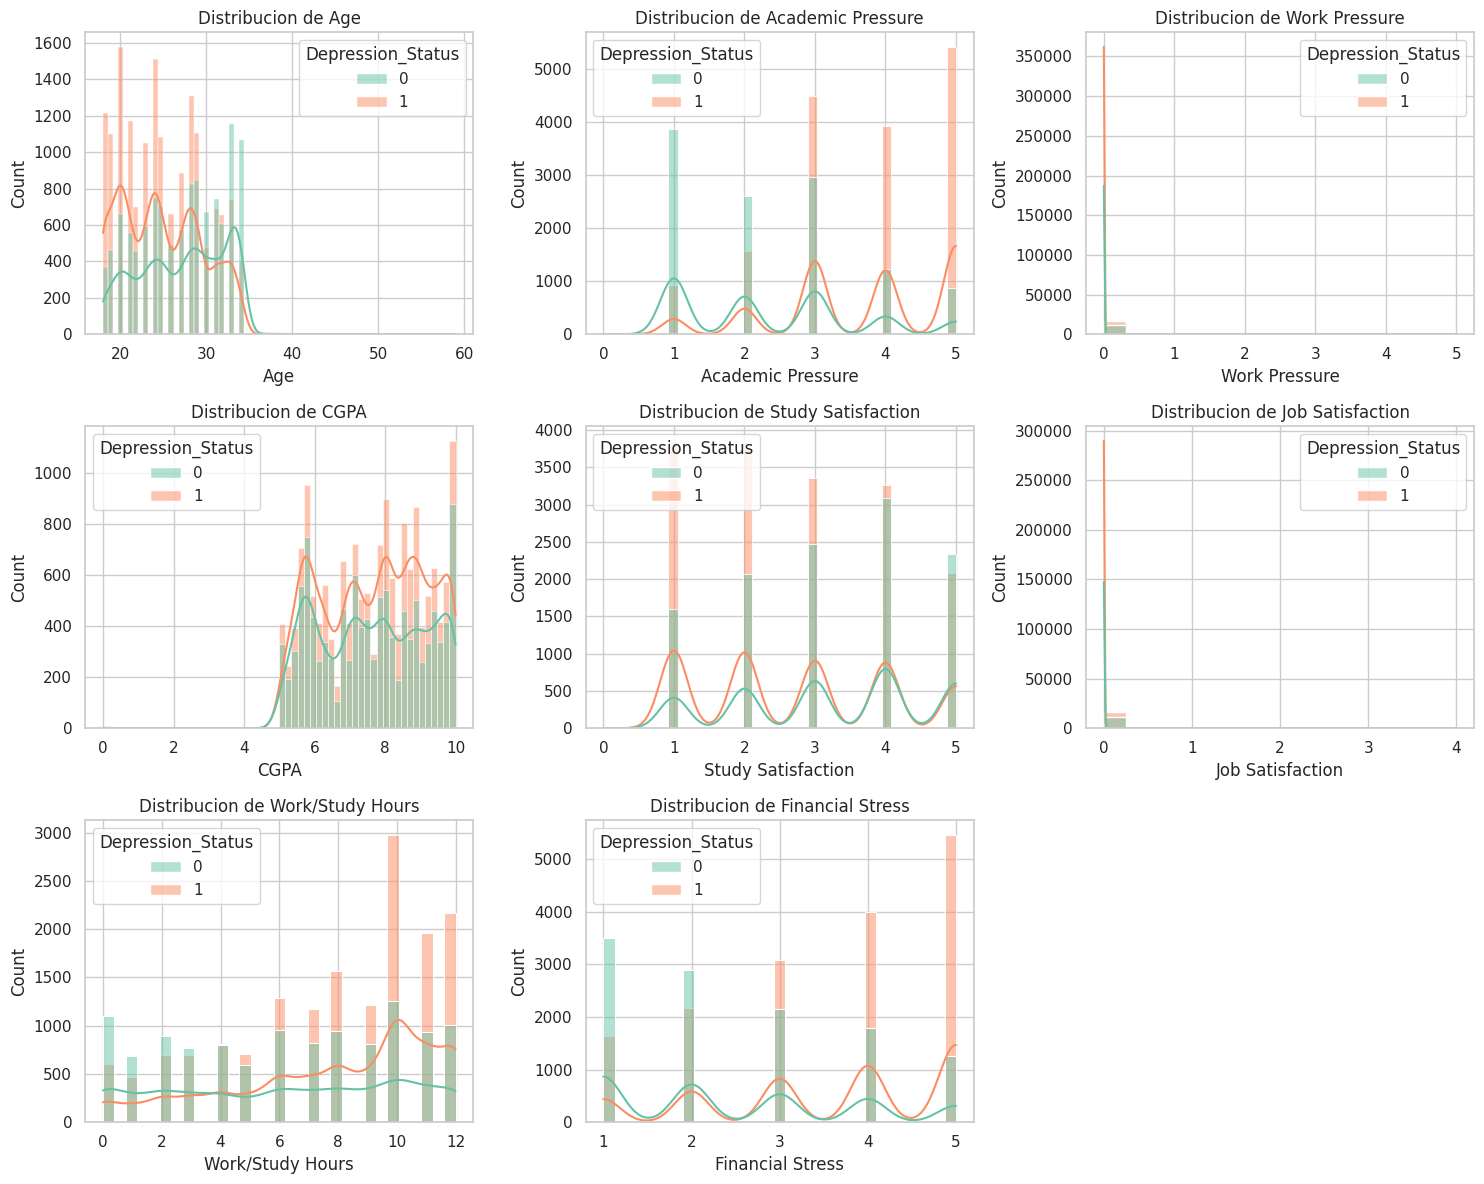

In [10]:
variables_numericas_interes = [
    'Age',
    'Academic Pressure',
    'Work Pressure',
    'CGPA',
    'Study Satisfaction',
    'Job Satisfaction',
    'Work/Study Hours',
    'Financial Stress',
]
variables_numericas_interes = [c for c in variables_numericas_interes if c in df_final.columns]

if variables_numericas_interes:
    n_cols = 3
    n_rows = int(np.ceil(len(variables_numericas_interes) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, variables_numericas_interes):
        sns.histplot(data=df_final, x=col, hue=TARGET, kde=True, ax=ax)
        ax.set_title(f'Distribucion de {col}')

    for ax in axes[len(variables_numericas_interes):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print('No se encontraron las variables numericas esperadas en el dataset.')

Depression_Status,0,1
Gender,,
Female,41.55,58.45
Male,41.37,58.63


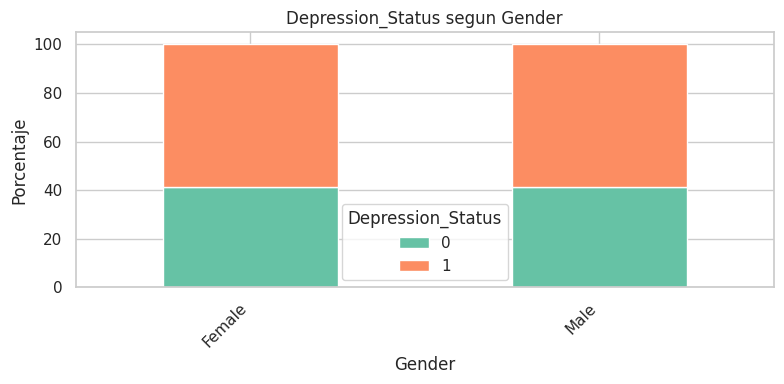

Depression_Status,0,1
Sleep Duration,,
5-6 hours,43.12,56.88
7-8 hours,40.50,59.50
Less than 5 hours,35.49,64.51
More than 8 hours,49.07,50.93


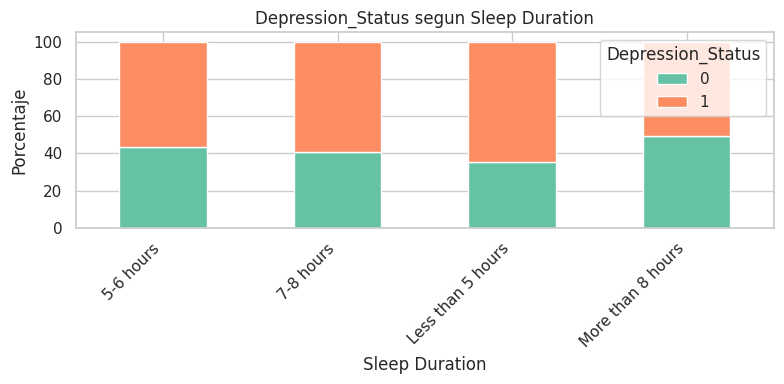

Depression_Status,0,1
Dietary Habits,,
Healthy,54.61,45.39
Moderate,43.98,56.02
Unhealthy,29.27,70.73


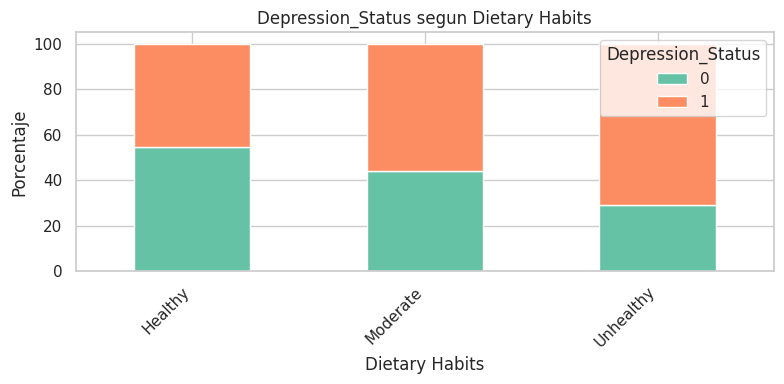

Depression_Status,0,1
Degree,,
B.Arch,41.07,58.93
B.Com,43.36,56.64
B.Ed,45.31,54.69
B.Pharm,47.16,52.84
B.Tech,43.14,56.86
BA,46.50,53.50
BBA,41.52,58.48
BCA,42.85,57.15
BE,45.51,54.49


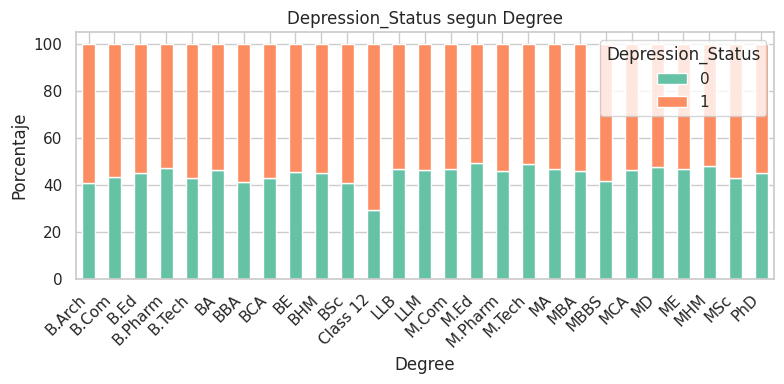

Depression_Status,0,1
Have you ever had suicidal thoughts ?,,
No,76.78,23.22
Yes,20.95,79.05


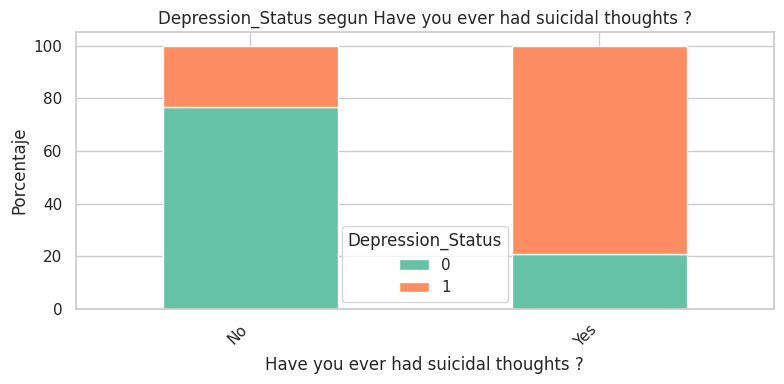

Depression_Status,0,1
Family History of Mental Illness,,
No,44.00,56.00
Yes,38.73,61.27


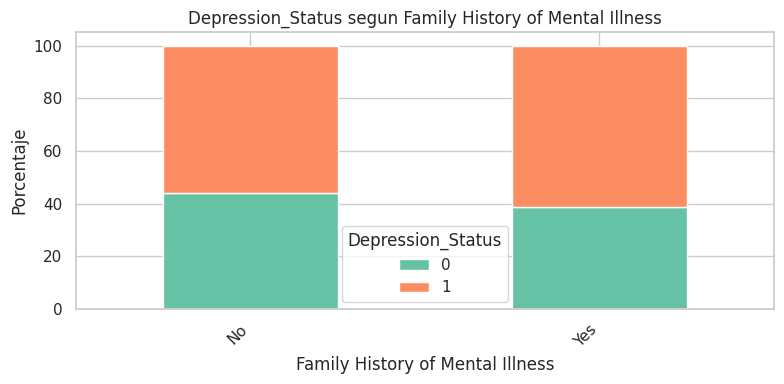

In [11]:
variables_categoricas_interes = [
    'Gender',
    'Sleep Duration',
    'Dietary Habits',
    'Degree',
    'Have you ever had suicidal thoughts ?',
    'Family History of Mental Illness',
]
variables_categoricas_interes = [c for c in variables_categoricas_interes if c in df_final.columns]

for col in variables_categoricas_interes:
    tabla = pd.crosstab(df_final[col], df_final[TARGET], normalize='index').mul(100).round(2)
    display(tabla)

    tabla.plot(kind='bar', stacked=True, figsize=(8, 4))
    plt.title(f'{TARGET} segun {col}')
    plt.xlabel(col)
    plt.ylabel('Porcentaje')
    plt.legend(title=TARGET)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

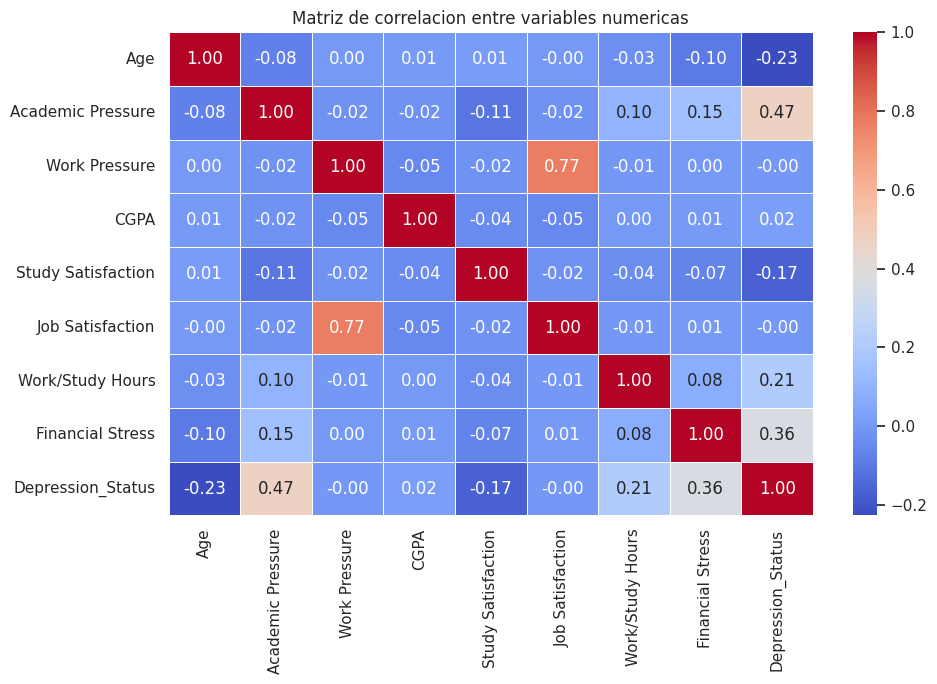

In [12]:
numericas = df_final.select_dtypes(include=np.number).columns.tolist()

if len(numericas) > 1:
    plt.figure(figsize=(10, 7))
    sns.heatmap(df_final[numericas].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title('Matriz de correlacion entre variables numericas')
    plt.tight_layout()
    plt.show()
else:
    print('No hay suficientes variables numericas para construir una matriz de correlacion.')

## 6. Preprocesamiento

Sobre `df_final`, se tratan valores nulos residuales, se codifican variables categoricas y se escalan variables numericas. La regresion logistica requiere una variable objetivo binaria.

In [13]:
def convertir_objetivo_binario(serie: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(serie):
        return serie

    normalizada = serie.astype(str).str.strip().str.lower()
    mapa = {
        'yes': 1,
        'y': 1,
        'si': 1,
        'sí': 1,
        'true': 1,
        'depressed': 1,
        '1': 1,
        'no': 0,
        'n': 0,
        'false': 0,
        'not depressed': 0,
        '0': 0,
    }
    convertida = normalizada.map(mapa)

    if convertida.isna().any():
        codigos, categorias = pd.factorize(normalizada)
        print('Categorias detectadas para la variable objetivo:', list(categorias))
        convertida = pd.Series(codigos, index=serie.index)

    return convertida

df_modelo = df_final.copy()
df_modelo[TARGET] = convertir_objetivo_binario(df_modelo[TARGET])
df_modelo = df_modelo.dropna(subset=[TARGET])
df_modelo[TARGET] = df_modelo[TARGET].astype(int)

if df_modelo[TARGET].nunique() != 2:
    raise ValueError('La variable objetivo no es binaria. Revisa los valores antes de aplicar regresion logistica.')

columnas_id = [c for c in df_modelo.columns if c.lower() in ['id', 'student_id', 'student id']]
X = df_modelo.drop(columns=[TARGET] + columnas_id)
y = df_modelo[TARGET]

columnas_numericas = X.select_dtypes(include=np.number).columns.tolist()
columnas_categoricas = X.select_dtypes(exclude=np.number).columns.tolist()

print('Columnas eliminadas por identificador:', columnas_id)
print('Variables numericas:', columnas_numericas)
print('Variables categoricas:', columnas_categoricas)

Columnas eliminadas por identificador: []
Variables numericas: ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress']
Variables categoricas: ['Gender', 'City', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']


## 7. Modelo de regresion logistica

Como `Depression_Status` representa una condicion binaria, se utiliza regresion logistica. Este modelo permite estimar la probabilidad de pertenecer a la clase positiva y analizar la direccion e intensidad relativa de las variables mediante sus coeficientes.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

preprocesador = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), columnas_numericas),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), columnas_categoricas),
    ]
)

modelo = Pipeline([
    ('preprocesador', preprocesador),
    ('regresion_logistica', LogisticRegression(max_iter=2000, class_weight='balanced')),
])

modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)
y_prob = modelo.predict_proba(X_test)[:, 1]

print('Modelo entrenado correctamente.')

Modelo entrenado correctamente.


## 8. Evaluacion del modelo

Se calculan metricas de clasificacion porque la variable objetivo es binaria.

In [15]:
metricas = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, zero_division=0),
    'Recall': recall_score(y_test, y_pred, zero_division=0),
    'F1-score': f1_score(y_test, y_pred, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, y_prob),
}

pd.DataFrame(metricas, index=['resultado']).T.round(4)

,resultado
Accuracy,0.8402
Precision,0.8783
Recall,0.8439
F1-score,0.8608
ROC-AUC,0.9184


              precision    recall  f1-score   support

           0       0.79      0.83      0.81      2313
           1       0.88      0.84      0.86      3268

    accuracy                           0.84      5581
   macro avg       0.83      0.84      0.84      5581
weighted avg       0.84      0.84      0.84      5581



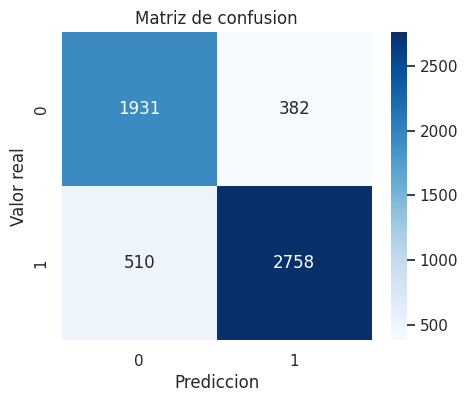

In [16]:
print(classification_report(y_test, y_pred, zero_division=0))

matriz = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusion')
plt.xlabel('Prediccion')
plt.ylabel('Valor real')
plt.show()

## 9. Relevancia de variables

Los coeficientes positivos indican variables asociadas con mayor probabilidad estimada de depresion. Los coeficientes negativos indican variables asociadas con menor probabilidad estimada, segun el modelo.

In [17]:
feature_names = modelo.named_steps['preprocesador'].get_feature_names_out()
coeficientes = modelo.named_steps['regresion_logistica'].coef_[0]

importancia = pd.DataFrame({
    'variable': feature_names,
    'coeficiente': coeficientes,
})
importancia['impacto_absoluto'] = importancia['coeficiente'].abs()
importancia = importancia.sort_values('impacto_absoluto', ascending=False)

importancia.head(20)

,variable,coeficiente,impacto_absoluto
68,cat__Profession_Student,-1.481125,1.481125
105,cat__Have you ever had suicidal thoughts ?_Yes,1.467338,1.467338
1,num__Academic Pressure,1.162630,1.162630
104,cat__Have you ever had suicidal thoughts ?_No,-1.051115,1.051115
7,num__Financial Stress,0.813968,0.813968
76,cat__Dietary Habits_Unhealthy,0.702697,0.702697
0,num__Age,-0.592022,0.592022
6,num__Work/Study Hours,0.443513,0.443513
57,cat__Profession_Architect,0.430115,0.430115
72,cat__Sleep Duration_Less than 5 hours,0.426664,0.426664


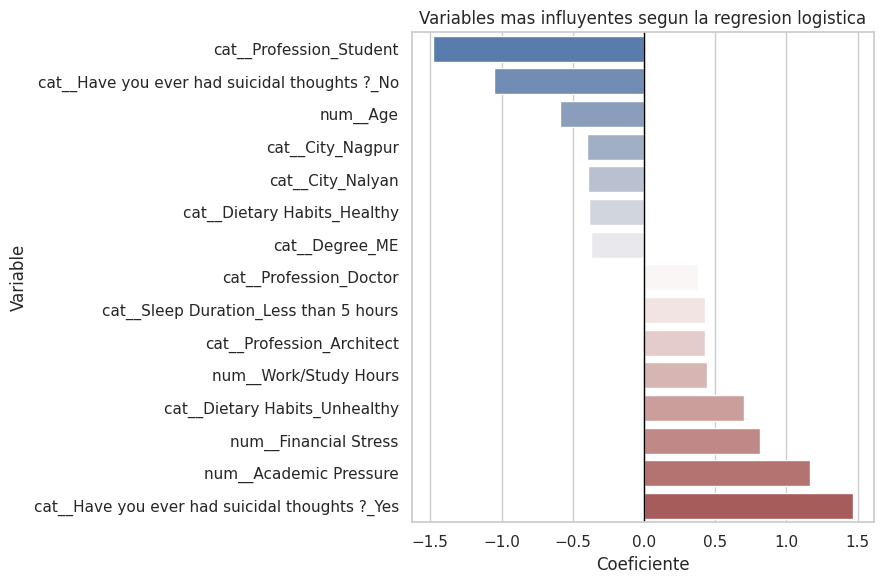

In [18]:
top_importancia = importancia.head(15).sort_values('coeficiente')

plt.figure(figsize=(9, 6))
sns.barplot(data=top_importancia, x='coeficiente', y='variable', palette='vlag')
plt.axvline(0, color='black', linewidth=1)
plt.title('Variables mas influyentes segun la regresion logistica')
plt.xlabel('Coeficiente')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

## 10. Interpretacion de resultados

Con base en el EDA y en los coeficientes del modelo, se deben interpretar los factores mas influyentes. Algunas guias para redactar el analisis final son:

- Si `Academic Pressure` aparece con coeficiente positivo, una mayor presion academica se asocia con mayor probabilidad estimada de depresion.
- Si `Study Satisfaction` aparece con coeficiente negativo, una mayor satisfaccion con los estudios se asocia con menor probabilidad estimada de depresion.
- Si variables como `Sleep Duration`, `Dietary Habits`, `Financial Stress` o antecedentes familiares aparecen entre las mas importantes, pueden considerarse factores relevantes de estilo de vida, contexto economico o salud mental familiar.
- Las asociaciones del modelo no prueban causalidad; sirven para identificar patrones que pueden apoyar estrategias de prevencion, deteccion temprana y acompanamiento.

### Conclusion preliminar

Este analisis permite relacionar variables academicas, demograficas y de estilo de vida con el estado de depresion reportado por los estudiantes. La regresion logistica facilita tanto la prediccion como la interpretacion de los factores asociados, aunque los resultados deben complementarse con criterio profesional y consideraciones eticas en salud mental.